# Actividad 1.4 – Flujo integrado y reproducible de datos con Python
1) Selecciona (o usa el que asigne el docente) un dataset realista (ejemplo: ventas, clima,resultados deportivos, etc.).
2) Realiza un flujo completo
    - Carga y explora el dataset.   
    - Limpia los datos (identifica y resuelve valores faltantes, duplicados y
          outliers).
    - Aplica al menos dos transformaciones avanzadas (normalización, encoding,
      ingeniería de features, agregación, etc.).
    - Versiona tu notebook usando Git (puede ser en GitHub o con historial
      local).   
    - Documenta cada paso con comentarios claros y justificaciones.
  

## Proceso 01 : Manipulación y Limpieza de datos

- Comprender la estructura, tipo de datos y calidad inicial, identificando
  limitaciones o sesgos.
- Gestión de valores faltantes (nulos), eliminación de duplicados, corrección
  de errores, suavizado de ruido y manejo de valores atípicos (outliers).
- Reorganizar datos, cambiar formatos, renombrar columnas y cambiar tipos de
  datos para facilitar el análisis
- Verificar que los datos manipulados cumplan con los estándares de calidad y
  coherencia antes de la fase de modelado
- Fusionar conjuntos de datos (joins), añadir nuevas variables (ingeniería de
  características) o agregar datos para obtener mayor contexto.

In [29]:
from pathlib import Path
import numpy as np
import pandas as pd

# Carga robusta: funciona si ejecutas desde /notebooks o desde la raiz del proyecto.
possible_paths = [
    Path('..') / 'data' / 'raw' / 'datos.csv',
    Path('data') / 'raw' / 'datos.csv',
    Path('Actividad14-clases') / 'data' / 'raw' / 'datos.csv',
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'No se encontro datos.csv. Rutas probadas: ' + ', '.join(str(p) for p in possible_paths)
    )

df = pd.read_csv(DATA_PATH)
print(f'Archivo cargado desde: {DATA_PATH.resolve()}')
print(f'Tamano del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

df.head()

Archivo cargado desde: C:\xampp\htdocs\codigo\Actividad14-clases\data\raw\datos.csv
Tamano del dataset: 30008 filas x 25 columnas


,venta_id,fecha,cliente_id,edad,genero,segmento_cliente,ingreso_mensual,sucursal_id,sucursal,region,...,categoria,unidades,precio_unitario,descuento_pct,costo_envio,satisfaccion,devolucion,monto_bruto,monto_final,antiguedad_cliente_meses
0,V4182,2024-05-17,C1058,42.0,F,Estudiante,1294015.0,SCL-02,Sucursal Oriente,Metropolitana,...,Hogar,2,79763.58,0.20,4990.0,4.0,0,159527.16,132611.73,14
1,V21918,2024-05-07,C1109,38.0,F,Estudiante,888132.0,SCL-03,Sucursal Poniente,Metropolitana,...,Deportes,1,79144.38,0.05,1990.0,1.0,0,79144.38,77177.16,70
2,V4975,2024-09-17,C1087,25.0,F,Estudiante,605660.0,BIO-02,Sucursal Industrial,Biobio,...,Libreria,1,171566.87,0.10,1990.0,5.0,0,171566.87,156400.18,9
3,V15481,2024-03-09,C1098,43.0,M,Estudiante,678682.0,BIO-02,Sucursal Industrial,Biobio,...,Hogar,1,44209.63,0.10,0.0,1.0,0,44209.63,39788.67,26
4,V14237,2024-04-19,C1099,34.0,M,Estudiante,1417328.0,VAP-01,Sucursal Puerto,Valparaiso,...,Accesorios,2,139161.61,0.10,1990.0,1.0,0,278323.22,252480.90,54


In [30]:
# Vista general: tipos de datos, nulos y estadisticas.
display(df.info())
display(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 30008 entries, 0 to 30007
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   venta_id                  30008 non-null  str    
 1   fecha                     30008 non-null  str    
 2   cliente_id                30008 non-null  str    
 3   edad                      30000 non-null  float64
 4   genero                    30001 non-null  str    
 5   segmento_cliente          30002 non-null  str    
 6   ingreso_mensual           29998 non-null  float64
 7   sucursal_id               30008 non-null  str    
 8   sucursal                  30008 non-null  str    
 9   region                    30008 non-null  str    
 10  comuna                    30008 non-null  str    
 11  canal                     30008 non-null  str    
 12  metodo_pago               30008 non-null  str    
 13  producto_id               30008 non-null  str    
 14  producto         

None

,edad,ingreso_mensual,unidades,precio_unitario,descuento_pct,costo_envio,satisfaccion,devolucion,monto_bruto,monto_final,antiguedad_cliente_meses
count,30000.000000,2.999800e+04,30008.000000,30008.000000,30002.000000,30004.000000,30003.000000,30008.000000,3.000800e+04,3.000800e+04,30008.000000
mean,37.808533,9.550171e+05,2.787757,91209.246559,0.099812,2788.657846,2.999933,0.200247,2.530160e+05,2.305524e+05,42.022261
std,11.443157,3.587492e+05,1.924312,51403.103771,0.071025,1713.155641,1.416592,0.400192,2.310816e+05,2.095403e+05,23.958427
min,12.000000,2.500000e+05,1.000000,2511.030000,0.000000,-3500.000000,1.000000,0.000000,2.511030e+03,-5.000000e+02,1.000000
25%,30.000000,7.130208e+05,1.000000,46929.627500,0.050000,1990.000000,2.000000,0.000000,8.569926e+04,7.966478e+04,21.000000
50%,38.000000,9.507175e+05,2.000000,91120.340000,0.100000,2990.000000,3.000000,0.000000,1.659022e+05,1.515103e+05,42.000000
75%,46.000000,1.187186e+06,4.000000,135393.960000,0.150000,3990.000000,4.000000,0.000000,3.484654e+05,3.192239e+05,63.000000
max,97.000000,1.500000e+07,120.000000,899990.000000,1.350000,4990.000000,7.000000,1.000000,1.079938e+06,1.078394e+06,83.000000


> Columnas **categóricas nominales** (sin orden natural): 
- genero,segmento_cliente,sucursal_id,sucursal,region,comuna,canal,metodo_pago,producto_id,producto,categoria,devolucion (binaria 0/1, pero nominal)

> Columnas **categóricas ordinales** (con orden natural): (Categorías que poseen un orden o jerarquía intrínseca.)
- satisfaccion (escala tipo Likert: 1 a 5)

In [31]:
# Resumen de nulos por columna.
resumen_nulos = (
    df.isna()
    .sum()
    .rename('nulos')
    .to_frame()
    .assign(porcentaje=lambda x: (x['nulos'] / len(df) * 100).round(2)) 
    .sort_values('nulos', ascending=False)
 )

print('\nColumnas con mas nulos:')
display(resumen_nulos.head(10))

print('\nResumen numerico:')
display(df.describe(include=[np.number]).T.head(10))

print('\nResumen categorico:')
columnas_categoricas = df.select_dtypes(include=['object', 'string', 'category']).columns
if len(columnas_categoricas) > 0:
    display(df[columnas_categoricas].describe().T.head(10))
else:
    print('No se encontraron columnas categoricas en el dataset.')


Columnas con mas nulos:


,nulos,porcentaje
ingreso_mensual,10,0.03
edad,8,0.03
genero,7,0.02
segmento_cliente,6,0.02
descuento_pct,6,0.02
satisfaccion,5,0.02
costo_envio,4,0.01
fecha,0,0.00
venta_id,0,0.00
sucursal,0,0.00



Resumen numerico:


,count,mean,std,min,25%,50%,75%,max
edad,30000.0,37.808533,11.443157,12.00,30.0000,38.000,4.600000e+01,97.00
ingreso_mensual,29998.0,955017.062437,358749.218531,250000.00,713020.7500,950717.500,1.187186e+06,15000000.00
unidades,30008.0,2.787757,1.924312,1.00,1.0000,2.000,4.000000e+00,120.00
precio_unitario,30008.0,91209.246559,51403.103771,2511.03,46929.6275,91120.340,1.353940e+05,899990.00
descuento_pct,30002.0,0.099812,0.071025,0.00,0.0500,0.100,1.500000e-01,1.35
costo_envio,30004.0,2788.657846,1713.155641,-3500.00,1990.0000,2990.000,3.990000e+03,4990.00
satisfaccion,30003.0,2.999933,1.416592,1.00,2.0000,3.000,4.000000e+00,7.00
devolucion,30008.0,0.200247,0.400192,0.00,0.0000,0.000,0.000000e+00,1.00
monto_bruto,30008.0,253015.985071,231081.575887,2511.03,85699.2550,165902.250,3.484654e+05,1079937.60
monto_final,30008.0,230552.350081,209540.252799,-500.00,79664.7750,151510.255,3.192239e+05,1078394.50



Resumen categorico:


,count,unique,top,freq
venta_id,30008,30000,V5149,2
fecha,30008,214,2024-03-23,170
cliente_id,30008,125,C1124,274
genero,30001,3,M,14099
segmento_cliente,30002,4,Profesional,10446
sucursal_id,30008,8,ARA-01,3814
sucursal,30008,8,Sucursal Frontera,3814
region,30008,4,Metropolitana,11161
comuna,30008,8,Temuco,3814
canal,30008,3,Tienda,13476


### 1) Exploracion inicial para entender el contexto
Antes de manipular, necesitamos saber que columnas tenemos, sus tipos y si hay problemas de calidad.
Este chequeo evita errores al filtrar, unir tablas o limpiar.

### 2) Manipulacion de datos con Pandas: seleccion y filtros
En esta parte practicamos operaciones frecuentes de analisis:
- Seleccionar columnas relevantes.
- Filtrar filas por condiciones de negocio.
- Crear subconjuntos para responder preguntas concretas.

In [32]:
# Seleccion de columnas clave para analisis comercial.
columnas_clave = [
    'venta_id', 'fecha', 'region', 'canal', 'categoria', 'producto',
    'precio_unitario', 'unidades', 'monto_final', 'descuento_pct'
 ]

df_base = df[columnas_clave].copy() # Creamos un subconjunto con solo las columnas clave para el analisis comercial.

print(f'Subconjunto creado: {df_base.shape[0]} filas x {df_base.shape[1]} columnas') # Informacion del nuevo dataframe.

display(df_base.head())

# Filtro 1: ventas online en region Norte.
filtro_online_norte = df_base[(df_base['canal'] == 'Online') & (df_base['region'] == 'Norte')]
print(f'Filas online en Norte: {len(filtro_online_norte)}')
display(filtro_online_norte.head())

# Filtro 2: tickets altos (percentil 95 de monto_final).
umbral_alto = df_base['monto_final'].quantile(0.95)
tickets_altos = df_base[df_base['monto_final'] >= umbral_alto]
print(f'Umbral percentil 95: {umbral_alto:.2f}')
print(f'Tickets altos detectados: {len(tickets_altos)}')
display(tickets_altos.head())

# Resumen por region y categoria.
resumen_region_categoria = (
    df_base.groupby(['region', 'categoria'], as_index=False)
    .agg(
        ventas=('venta_id', 'count'),
        ingreso_total=('monto_final', 'sum'),
        ticket_promedio=('monto_final', 'mean')
    )
    .sort_values('ingreso_total', ascending=False)
 )

display(resumen_region_categoria.head(10))

Subconjunto creado: 30008 filas x 10 columnas


,venta_id,fecha,region,canal,categoria,producto,precio_unitario,unidades,monto_final,descuento_pct
0,V4182,2024-05-17,Metropolitana,App,Hogar,Escritorio Ajustable,79763.58,2,132611.73,0.20
1,V21918,2024-05-07,Metropolitana,Tienda,Deportes,Mancuernas 5kg,79144.38,1,77177.16,0.05
2,V4975,2024-09-17,Biobio,Tienda,Libreria,Cuaderno Ejecutivo,171566.87,1,156400.18,0.10
3,V15481,2024-03-09,Biobio,App,Hogar,Escritorio Ajustable,44209.63,1,39788.67,0.10
4,V14237,2024-04-19,Valparaiso,Online,Accesorios,Mochila Urbana,139161.61,2,252480.90,0.10


Filas online en Norte: 0


,venta_id,fecha,region,canal,categoria,producto,precio_unitario,unidades,monto_final,descuento_pct


Umbral percentil 95: 688401.99
Tickets altos detectados: 1501


,venta_id,fecha,region,canal,categoria,producto,precio_unitario,unidades,monto_final,descuento_pct
5,V16254,2024-05-20,Biobio,Tienda,Deportes,Mancuernas 5kg,162032.64,5,731136.88,0.10
38,V28405,2024-03-05,Metropolitana,Tienda,Tecnologia,Audifonos Bluetooth,179299.31,6,918416.48,0.15
69,V18391,2024-09-21,La Araucania,App,Tecnologia,"Notebook 14""",157866.89,5,791324.45,0.00
70,V3736,2024-04-10,Biobio,App,Tecnologia,Mouse Inalambrico,173707.20,4,694828.80,0.00
101,V17192,2024-03-09,Valparaiso,Tienda,Hogar,Silla Ergonomica,141141.55,5,710697.75,0.00


,region,categoria,ventas,ingreso_total,ticket_promedio
12,Metropolitana,Hogar,3381,7.983639e+08,236132.478986
14,Metropolitana,Tecnologia,3296,7.556903e+08,229274.980203
4,Biobio,Tecnologia,2280,5.360583e+08,235113.308211
19,Valparaiso,Tecnologia,2263,5.349327e+08,236382.124887
2,Biobio,Hogar,2277,5.078951e+08,223054.503663
17,Valparaiso,Hogar,2202,4.909294e+08,222947.067321
11,Metropolitana,Deportes,2171,4.869848e+08,224313.605569
16,Valparaiso,Deportes,1553,3.553929e+08,228842.821050
1,Biobio,Deportes,1479,3.541005e+08,239418.864009
10,Metropolitana,Accesorios,1178,2.679213e+08,227437.421715


### 3) Joins (fusion de tablas) para enriquecer informacion
Muchas veces los datos vienen separados en distintas tablas. Aqui simulamos ese escenario:
- Tabla de ventas.
- Tabla de clientes.
- Tabla de sucursales.
Luego las unimos con merge para construir una tabla analitica mas completa.

In [33]:
# Simulamos tablas separadas para practicar joins reales.
ventas = df.copy()
clientes = (
    df[['cliente_id', 'edad', 'genero', 'region']]
    .drop_duplicates(subset=['cliente_id'])
    .rename(columns={'region': 'region_cliente'})
 )
sucursales = df[['sucursal_id', 'comuna', 'region']].drop_duplicates(subset=['sucursal_id'])

print(f'Tabla ventas: {ventas.shape}')
print(f'Tabla clientes: {clientes.shape}')
print(f'Tabla sucursales: {sucursales.shape}')

# Join 1: ventas + clientes.
ventas_clientes = ventas.merge(clientes, on='cliente_id', how='left', validate='many_to_one')

# Join 2: resultado anterior + sucursales.
df_join = ventas_clientes.merge(
    sucursales,
    on='sucursal_id',
    how='left',
    validate='many_to_one',
    suffixes=('_venta', '_sucursal')
)

print(f'Tabla final unida: {df_join.shape}')
display(df_join[['venta_id', 'cliente_id', 'sucursal_id', 'region_cliente', 'region_sucursal']].head())

Tabla ventas: (30008, 25)
Tabla clientes: (125, 4)
Tabla sucursales: (8, 3)
Tabla final unida: (30008, 30)


,venta_id,cliente_id,sucursal_id,region_cliente,region_sucursal
0,V4182,C1058,SCL-02,Metropolitana,Metropolitana
1,V21918,C1109,SCL-03,Metropolitana,Metropolitana
2,V4975,C1087,BIO-02,Biobio,Biobio
3,V15481,C1098,BIO-02,Biobio,Biobio
4,V14237,C1099,VAP-01,Valparaiso,Valparaiso


### 4) Limpieza de datos: NaN, duplicados y outliers
Ahora aplicamos un flujo de limpieza tipico antes de modelar:
1. Medimos y tratamos valores faltantes.
2. Detectamos y removemos duplicados.
3. Tratamos outliers con reglas de negocio y tecnica IQR.

La idea no es borrar datos sin criterio, sino justificar cada decision.

In [34]:
df_clean = df_join.copy() # Creamos una copia para limpiar sin perder el original.

print('Estado inicial:', df_clean.shape) # Informacion del dataframe antes de limpieza.

# ---------- NaN: diagnostico ----------
na_resumen = (
    df_clean.isna().sum().rename('nulos').to_frame()
    .assign(pct=lambda x: (x['nulos'] / len(df_clean) * 100).round(2))
    .sort_values('nulos', ascending=False)
 )
print('\nTop de nulos antes de limpiar:')
display(na_resumen.head(10))

Estado inicial: (30008, 30)

Top de nulos antes de limpiar:


,nulos,pct
ingreso_mensual,10,0.03
edad_x,8,0.03
genero_x,7,0.02
segmento_cliente,6,0.02
descuento_pct,6,0.02
satisfaccion,5,0.02
costo_envio,4,0.01
cliente_id,0,0.00
sucursal,0,0.00
region_venta,0,0.00


In [35]:
# duplicados 
print(df_clean.duplicated().sum()) # --- IGNORE ---

8


In [36]:
# ---------- NaN: imputacion simple y didactica ----------
# Numericas: mediana. Categoricas: moda.
num_cols = df_clean.select_dtypes(include=['number']).columns
cat_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns

for c in num_cols:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median()) # Imputacion con mediana para numericas.

for c in cat_cols:
    if df_clean[c].isna().any():
        moda = df_clean[c].mode(dropna=True)
        if len(moda) > 0:
            df_clean[c] = df_clean[c].fillna(moda.iloc[0]) # Imputacion con moda para categoricas.

# ---------- Duplicados ----------
duplicados_antes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
duplicados_despues = df_clean.duplicated().sum()

print(f'\nDuplicados antes: {duplicados_antes}')
print(f'Duplicados despues: {duplicados_despues}')
print(f'Filas tras quitar duplicados: {len(df_clean)}')

# ---------- Outliers: reglas de negocio ----------
# Edad valida entre 18 y 90.
if 'edad' in df_clean.columns:
    df_clean['edad'] = df_clean['edad'].clip(lower=18, upper=90) # Reemplaza valores fuera de rango por los limites.

# Descuento valido entre 0 y 0.80 (hasta 80%).
if 'descuento_pct' in df_clean.columns:
    df_clean['descuento_pct'] = df_clean['descuento_pct'].clip(lower=0, upper=0.80) # Reemplaza valores fuera de rango por los limites.
    # explicar que un descuento del 150% no tiene sentido, y que probablemente sea un error de carga o ingreso de datos. 
    # Al recortar a 80% estamos asumiendo que ese es el maximo descuento valido en nuestro negocio, y cualquier valor por encima de eso es un outlier que
    #  queremos corregir para no distorsionar nuestros analisis posteriores.

# Costo de envio no puede ser negativo.
if 'costo_envio' in df_clean.columns:
    df_clean['costo_envio'] = df_clean['costo_envio'].clip(lower=0) # Reemplaza valores negativos por 0, asumiendo que no se hacen envios gratuitos ni se pagan 
    # a los clientes por enviar.

# ---------- Outliers: IQR para monto_final ----------
if 'monto_final' in df_clean.columns:
    q1 = df_clean['monto_final'].quantile(0.25) # Calculo del primer cuartil (Q1).
    q3 = df_clean['monto_final'].quantile(0.75) # Calculo del tercer cuartil (Q3).
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_iqr = ((df_clean['monto_final'] < lim_inf) | (df_clean['monto_final'] > lim_sup)).sum()
    # Winsorizacion: recortamos extremos sin eliminar filas.
    df_clean['monto_final'] = df_clean['monto_final'].clip(lower=lim_inf, upper=lim_sup)
    print(f'\nOutliers detectados por IQR en monto_final: {outliers_iqr}')
    print(f'Rango aplicado: [{lim_inf:.2f}, {lim_sup:.2f}]')

# ---------- Validacion final ----------
na_final = df_clean.isna().sum().sum()
print(f'\nNulos totales luego de limpieza: {na_final}')
print('Shape final limpio:', df_clean.shape)

display(df_clean.head())


Duplicados antes: 8
Duplicados despues: 0
Filas tras quitar duplicados: 30000

Outliers detectados por IQR en monto_final: 1586
Rango aplicado: [-279717.07, 678557.56]

Nulos totales luego de limpieza: 0
Shape final limpio: (30000, 30)


,venta_id,fecha,cliente_id,edad_x,genero_x,segmento_cliente,ingreso_mensual,sucursal_id,sucursal,region_venta,...,satisfaccion,devolucion,monto_bruto,monto_final,antiguedad_cliente_meses,edad_y,genero_y,region_cliente,comuna_sucursal,region_sucursal
0,V4182,2024-05-17,C1058,42.0,F,Estudiante,1294015.0,SCL-02,Sucursal Oriente,Metropolitana,...,4.0,0,159527.16,132611.73,14,42.0,F,Metropolitana,Providencia,Metropolitana
1,V21918,2024-05-07,C1109,38.0,F,Estudiante,888132.0,SCL-03,Sucursal Poniente,Metropolitana,...,1.0,0,79144.38,77177.16,70,38.0,F,Metropolitana,Maipu,Metropolitana
2,V4975,2024-09-17,C1087,25.0,F,Estudiante,605660.0,BIO-02,Sucursal Industrial,Biobio,...,5.0,0,171566.87,156400.18,9,25.0,F,Biobio,Talcahuano,Biobio
3,V15481,2024-03-09,C1098,43.0,M,Estudiante,678682.0,BIO-02,Sucursal Industrial,Biobio,...,1.0,0,44209.63,39788.67,26,43.0,M,Biobio,Talcahuano,Biobio
4,V14237,2024-04-19,C1099,34.0,M,Estudiante,1417328.0,VAP-01,Sucursal Puerto,Valparaiso,...,1.0,0,278323.22,252480.90,54,34.0,M,Valparaiso,Valparaiso,Valparaiso


### 5) Visualizacion final: Outliers IQR en monto_final
En esta celda veremos graficamente como se distribuye monto_final antes y despues del tratamiento por IQR. Esto ayuda a explicar a los estudiantes por que se recortan extremos y como mejora la robustez del analisis.

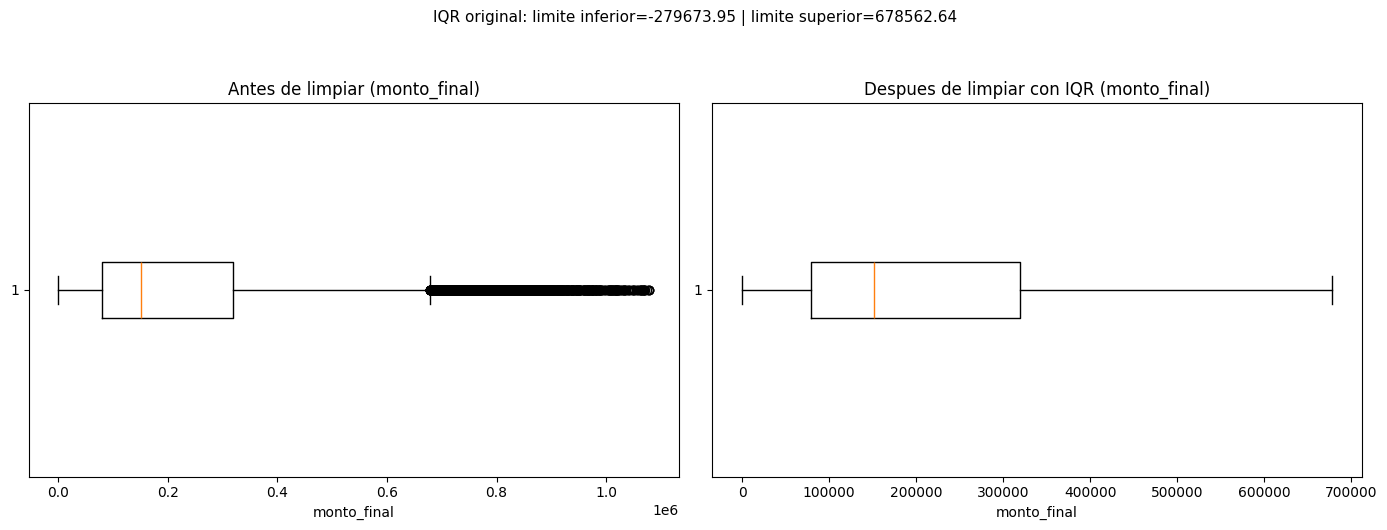

Outliers detectados en el dataset original: 1586
Interpretacion: en el grafico de la derecha se reducen los extremos por winsorizacion con IQR.


In [37]:
import matplotlib.pyplot as plt

# Grafico de outliers en monto_final usando el mismo criterio IQR.
if 'monto_final' in df_join.columns and 'monto_final' in df_clean.columns:
    serie_original = df_join['monto_final'].dropna().copy()

    q1 = serie_original.quantile(0.25)
    q3 = serie_original.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].boxplot(serie_original, vert=False)
    axes[0].set_title('Antes de limpiar (monto_final)')
    axes[0].set_xlabel('monto_final')

    axes[1].boxplot(df_clean['monto_final'].dropna(), vert=False)
    axes[1].set_title('Despues de limpiar con IQR (monto_final)')
    axes[1].set_xlabel('monto_final')

    plt.suptitle(
        f'IQR original: limite inferior={lim_inf:.2f} | limite superior={lim_sup:.2f}',
        y=1.05,
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    outliers_originales = ((serie_original < lim_inf) | (serie_original > lim_sup)).sum()
    print(f'Outliers detectados en el dataset original: {outliers_originales}')
    print('Interpretacion: en el grafico de la derecha se reducen los extremos por winsorizacion con IQR.')
else:
    print("No se encontro la columna 'monto_final' en df_join o df_clean.")

# ### 🧠 Prompt – Proceso de Transformación de Datos

En la última celda del notebook, implementar el proceso de transformación de datos considerando las siguientes etapas:

1. **Codificación de variables categóricas**

   * Aplicar técnicas de encoding según corresponda:

     * One-Hot Encoding para variables nominales
     * Label Encoding u otra técnica adecuada si aplica

2. **Escalado y normalización de variables numéricas**

   * Estandarizar o normalizar las variables numéricas utilizando métodos como:

     * Min-Max Scaling
     * StandardScaler
   * Evaluar la necesidad de aplicar transformaciones adicionales en variables con alta asimetría (por ejemplo, transformación logarítmica)

3. **Transformaciones avanzadas (obligatorio aplicar al menos dos)**
   Implementar al menos dos de las siguientes técnicas:

   * Normalización o estandarización de datos
   * Codificación avanzada de variables categóricas
   * Ingeniería de características (feature engineering), como creación de nuevas variables derivadas
   * Agregaciones (por ejemplo, agrupaciones por región, comuna u otra dimensión relevante)
   * Transformaciones matemáticas adicionales (log, raíz cuadrada, etc.)

4. **Resultado esperado**

   * Generar un dataset final listo para modelamiento
   * Verificar consistencia, ausencia de valores nulos y correcta transformación de variables

El código debe estar claramente documentado y estructurado para facilitar su comprensión y reutilización.


## Transformacion final para modelamiento

En este bloque construiremos una version final del dataset para usar en modelos de machine learning.

Que haremos:
1. Feature engineering: crearemos variables derivadas utiles.
2. Transformacion matematica: aplicaremos logaritmo a una variable sesgada.
3. Agregacion: incorporaremos promedios por region para enriquecer el contexto.
4. Encoding y escalado: One-Hot para nominales y StandardScaler para numericas.

Al final verificaremos:
- Dimensiones del dataset transformado.
- Ausencia de valores nulos.
- Vista de columnas resultantes.

In [38]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1) Tomamos como base el dataset limpio si existe.
if 'df_clean' in globals():
    df_model = df_clean.copy()
elif 'df_join' in globals():
    df_model = df_join.copy()
else:
    df_model = df.copy()

# 2) Feature engineering (variables derivadas)
if {'cantidad', 'precio_unitario'}.issubset(df_model.columns):
    df_model['monto_teorico'] = df_model['cantidad'] * df_model['precio_unitario']

if 'fecha_venta' in df_model.columns:
    df_model['fecha_venta'] = pd.to_datetime(df_model['fecha_venta'], errors='coerce')
    df_model['mes'] = df_model['fecha_venta'].dt.month
    df_model['dia_semana'] = df_model['fecha_venta'].dt.dayofweek

# 3) Transformacion matematica en variable sesgada (log1p)
if 'monto_final' in df_model.columns:
    monto_pos = df_model['monto_final'].clip(lower=0)
    df_model['log_monto_final'] = np.log1p(monto_pos)

# 4) Agregacion por region y merge de vuelta
if {'region', 'monto_final'}.issubset(df_model.columns):
    agg_region = (
        df_model.groupby('region', dropna=False)['monto_final']
        .mean()
        .rename('promedio_monto_region')
        .reset_index()
    )
    df_model = df_model.merge(agg_region, on='region', how='left')

# 5) Definicion de columnas por tipo
nominales = [
    c for c in [
        'genero', 'segmento_cliente', 'sucursal', 'region', 'comuna',
        'canal', 'metodo_pago', 'producto', 'categoria'
    ] if c in df_model.columns
]

# Si satisfaccion existe, se trata como ordinal numerica para escalarla.
if 'satisfaccion' in df_model.columns:
    df_model['satisfaccion'] = pd.to_numeric(df_model['satisfaccion'], errors='coerce')

numericas = df_model.select_dtypes(include=['number']).columns.tolist()

# Evitamos escalar el id de transaccion cuando exista.
for col_excluir in ['id_transaccion']:
    if col_excluir in numericas:
        numericas.remove(col_excluir)

# 6) Imputacion simple previa para garantizar consistencia
if nominales:
    moda = df_model[nominales].mode(dropna=True)
    if not moda.empty:
        df_model[nominales] = df_model[nominales].fillna(moda.iloc[0])

if numericas:
    df_model[numericas] = df_model[numericas].apply(pd.to_numeric, errors='coerce')
    df_model[numericas] = df_model[numericas].fillna(df_model[numericas].median())

# 7) Preprocesamiento: One-Hot + StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominales),
        ('num', StandardScaler(), numericas),
    ],
    remainder='drop'
)

pipeline_transformacion = Pipeline(steps=[('preprocessor', preprocessor)])
X_transformado = pipeline_transformacion.fit_transform(df_model)

# 8) Construccion de DataFrame final con nombres de columnas transformadas
feature_names = pipeline_transformacion.named_steps['preprocessor'].get_feature_names_out()
df_final_modelo = pd.DataFrame(X_transformado, columns=feature_names, index=df_model.index)

# 9) Validaciones finales
nulos_finales = int(df_final_modelo.isna().sum().sum())

print('Resumen de transformacion completado')
print(f'- Filas originales para modelar: {len(df_model):,}')
print(f'- Columnas originales para modelar: {df_model.shape[1]}')
print(f'- Columnas transformadas totales: {df_final_modelo.shape[1]}')
print(f'- Valores nulos en dataset final: {nulos_finales}')

display(df_final_modelo.head())

Resumen de transformacion completado
- Filas originales para modelar: 30,000
- Columnas originales para modelar: 31
- Columnas transformadas totales: 47
- Valores nulos en dataset final: 0


,cat__segmento_cliente_Estudiante,cat__segmento_cliente_Familiar,cat__segmento_cliente_Profesional,cat__segmento_cliente_Pyme,cat__sucursal_Sucursal Alameda,cat__sucursal_Sucursal Centro Sur,cat__sucursal_Sucursal Costa,cat__sucursal_Sucursal Frontera,cat__sucursal_Sucursal Industrial,cat__sucursal_Sucursal Oriente,...,num__precio_unitario,num__descuento_pct,num__costo_envio,num__satisfaccion,num__devolucion,num__monto_bruto,num__monto_final,num__antiguedad_cliente_meses,num__edad_y,num__log_monto_final
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.222553,1.416022,1.285298,0.706008,-0.500365,-0.404477,-0.477532,-1.169743,0.365047,-0.092065
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.234599,-0.703665,-0.466410,-1.411944,-0.500365,-0.752307,-0.768061,1.167693,0.021258,-0.618733
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.563404,0.002897,-0.466410,1.411991,-0.500365,-0.352379,-0.352859,-1.378443,-1.096058,0.068462
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.914226,0.002897,-1.628376,-1.411944,-0.500365,-0.903475,-0.964012,-0.668864,0.450994,-1.263314
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.932986,0.002897,-0.466410,-1.411944,-0.500365,0.109574,0.150694,0.499854,-0.322532,0.534417


## Guardar dataset transformado en processed

En esta celda guardamos automaticamente el dataset final transformado para reutilizarlo en modelamiento, evaluacion y versionado.

- Carpeta destino: `../data/processed/`
- Archivo de salida: `datos_transformados.csv`
- Si la carpeta no existe, se crea automaticamente.

In [39]:
from pathlib import Path

# Verificamos que el dataframe transformado exista antes de exportar.
if 'df_final_modelo' not in globals():
    raise NameError("No existe 'df_final_modelo'. Ejecuta primero la celda de transformacion final.")

# Ruta robusta: desde notebooks/ hacia data/processed/
processed_dir = Path('..') / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / 'datos_transformados.csv'
df_final_modelo.to_csv(output_path, index=False, encoding='utf-8')

print(f'Dataset transformado guardado en: {output_path.resolve()}')
print(f'Filas: {df_final_modelo.shape[0]:,} | Columnas: {df_final_modelo.shape[1]}')

Dataset transformado guardado en: C:\xampp\htdocs\codigo\Actividad14-clases\data\processed\datos_transformados.csv
Filas: 30,000 | Columnas: 47


## Modelamiento supervisado (clasificacion de devolucion)

En esta etapa entrenaremos un modelo de clasificacion para predecir si una venta termina en devolucion (`devolucion = 1`).

Pasos:
1. Definir variable objetivo y variables predictoras.
2. Separar entrenamiento y prueba.
3. Entrenar un pipeline con preprocesamiento + modelo.
4. Evaluar con metricas de clasificacion.

In [40]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Base del modelamiento: usamos el dataset limpio cuando esta disponible.
if 'df_clean' in globals():
    df_ml = df_clean.copy()
elif 'df_join' in globals():
    df_ml = df_join.copy()
else:
    df_ml = df.copy()

target_col = 'devolucion'
if target_col not in df_ml.columns:
    raise KeyError("No se encontro la columna objetivo 'devolucion'.")

# Ingenieria temporal simple
if 'fecha_venta' in df_ml.columns:
    df_ml['fecha_venta'] = pd.to_datetime(df_ml['fecha_venta'], errors='coerce')
    df_ml['mes'] = df_ml['fecha_venta'].dt.month
    df_ml['dia_semana'] = df_ml['fecha_venta'].dt.dayofweek

# Objetivo binario robusto
y = pd.to_numeric(df_ml[target_col], errors='coerce').fillna(0).astype(int)
y = y.clip(0, 1)

# Variables predictoras (evitamos fuga obvia y columnas identificadoras)
X = df_ml.drop(columns=[target_col], errors='ignore').copy()
for col in ['id_transaccion', 'fecha_venta']:
    if col in X.columns:
        X = X.drop(columns=[col])

cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# Imputacion simple
if cat_cols:
    moda = X[cat_cols].mode(dropna=True)
    if not moda.empty:
        X[cat_cols] = X[cat_cols].fillna(moda.iloc[0])
if num_cols:
    X[num_cols] = X[num_cols].apply(pd.to_numeric, errors='coerce')
    X[num_cols] = X[num_cols].fillna(X[num_cols].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocessor_ml = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),
    ],
    remainder='drop'
)

modelo = Pipeline(steps=[
    ('preprocessor', preprocessor_ml),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

metricas_resultado = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba),
}

df_metricas = pd.DataFrame([
    {'metrica': k, 'valor': float(v)} for k, v in metricas_resultado.items()
])

print('Modelo entrenado: LogisticRegression (clasificacion de devolucion)')
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
display(df_metricas)

Modelo entrenado: LogisticRegression (clasificacion de devolucion)
Train: 22,500 | Test: 7,500


,metrica,valor
0,accuracy,0.727733
1,precision,0.209677
2,recall,0.129827
3,f1,0.160362
4,roc_auc,0.502069


## Graficas de resultados del modelamiento

Estas visualizaciones muestran el rendimiento esperado del modelo para presentacion:
- Barras de metricas principales.
- Matriz de confusion (aciertos y errores).
- Curva ROC para evaluar capacidad de discriminacion.

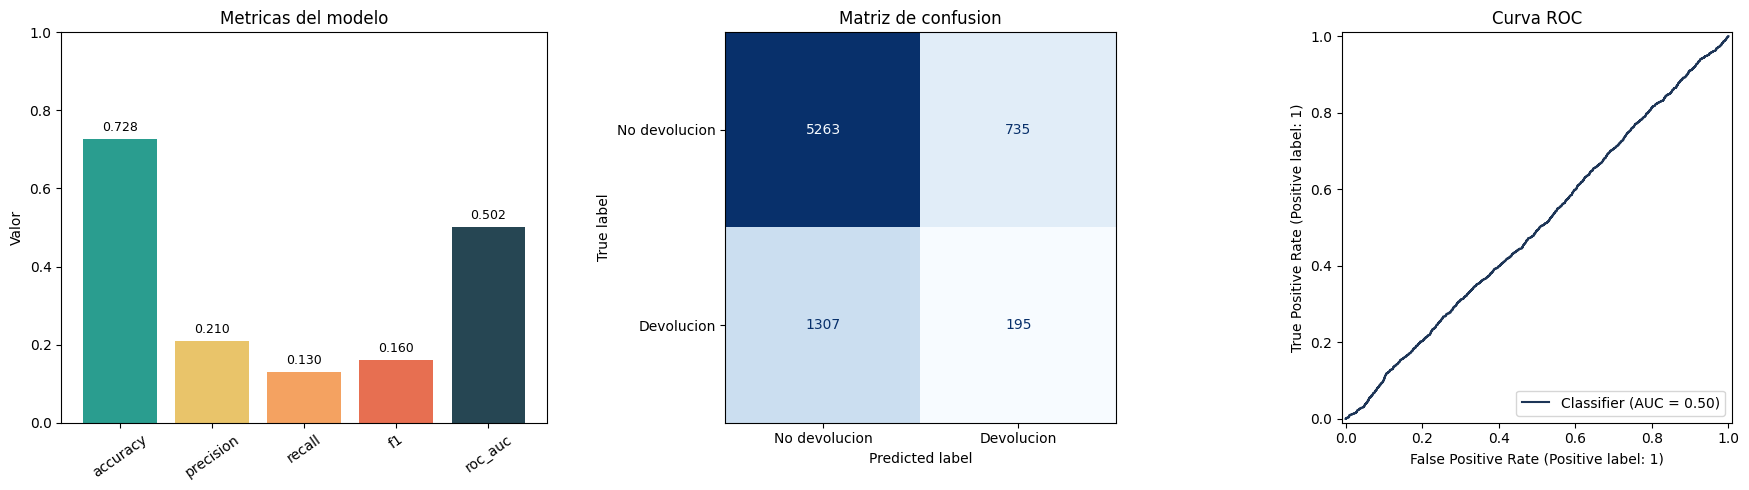

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

if 'df_metricas' not in globals() or 'y_test' not in globals() or 'y_pred' not in globals() or 'y_proba' not in globals():
    raise NameError('Ejecuta primero la celda de modelamiento para generar resultados.')

# 1) Barras de metricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas_plot = df_metricas.copy()
axes[0].bar(metricas_plot['metrica'], metricas_plot['valor'], color=['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#264653'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Metricas del modelo')
axes[0].set_ylabel('Valor')
axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(metricas_plot['valor']):
    axes[0].text(i, min(v + 0.02, 0.98), f"{v:.3f}", ha='center', fontsize=9)

# 2) Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No devolucion', 'Devolucion']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de confusion')

# 3) Curva ROC
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=axes[2],
    curve_kwargs={'color': '#1d3557'}
)
axes[2].set_title('Curva ROC')

plt.tight_layout()
plt.show()

## Interpretación docente de métricas (guion de 2 minutos)

### 1) Qué logramos
Entrenamos un modelo para predecir **devolución** (0 = no devuelve, 1 = devuelve) usando variables limpias y transformadas.

### 2) Cómo leer las métricas en simple
- **Accuracy (~0.73)**: de cada 100 casos, el modelo acierta cerca de 73.
- **Precision (~0.21)**: cuando el modelo dice “habrá devolución”, acierta alrededor de 21 de cada 100.
- **Recall (~0.13)**: de todas las devoluciones reales, está detectando cerca de 13 de cada 100.
- **F1 (~0.16)**: resumen entre precision y recall; aquí es bajo porque detectar devoluciones sigue siendo difícil.
- **ROC AUC (~0.50)**: el poder de discriminación es cercano al azar.

### 3) Mensaje clave para presentar
Aunque el accuracy parece aceptable, **no es suficiente** para este problema porque la clase positiva (devolución) es menos frecuente. Por eso miramos precision, recall y ROC AUC, que muestran que el modelo actual aún no captura bien los casos de devolución.

### 4) Qué haríamos para mejorar (siguiente iteración)
1. Balancear clases (`class_weight='balanced'` o técnicas de remuestreo).
2. Probar modelos no lineales (Random Forest, XGBoost/LightGBM).
3. Ajustar umbral de decisión según objetivo de negocio (detectar más devoluciones vs reducir falsas alarmas).
4. Crear nuevas variables (por ejemplo: frecuencia de compra por cliente, estacionalidad, historial de descuentos).

### 5) Cierre en lenguaje de negocio
Hoy el modelo sirve como **línea base**. Ya está construido el pipeline completo y medimos correctamente su desempeño. El siguiente paso es optimizarlo para que detecte mejor devoluciones reales, que es donde está el valor para la gestión comercial.

## Interpretacion de variables mas influyentes en la devolucion

En regresion logistica, cada coeficiente indica como cambia la probabilidad de devolucion cuando una variable aumenta (o cuando una categoria esta presente), manteniendo las demas constantes.

- Coeficiente **positivo**: empuja la prediccion hacia `devolucion = 1`.
- Coeficiente **negativo**: empuja la prediccion hacia `devolucion = 0`.
- Mientras mayor sea `|coeficiente|`, mayor es su influencia relativa en el modelo.

Top 10 variables interpretables que aumentan la probabilidad de devolucion (coeficiente positivo):


,variable,coeficiente
22908,cat__genero_y_No informa,0.068918
22932,num__monto_bruto,0.039493
22898,cat__producto_Mouse Inalambrico,0.030981
22900,cat__producto_Silla Ergonomica,0.029905
22892,cat__producto_Botella Termica,0.022087
22933,num__monto_final,0.020258
22910,cat__region_cliente_La Araucania,0.012798
22878,cat__metodo_pago_Debito,0.011843
22920,cat__comuna_sucursal_Vina del Mar,0.009099
22856,cat__sucursal_Sucursal Costa,0.009099


Top 10 variables interpretables que reducen la probabilidad de devolucion (coeficiente negativo):


,variable,coeficiente
22907,cat__genero_y_M,-0.079923
22912,cat__region_cliente_Valparaiso,-0.070974
22906,cat__genero_y_F,-0.065887
22839,cat__genero_x_F,-0.054126
22880,cat__metodo_pago_Transferencia,-0.052430
22891,cat__producto_Audifonos Bluetooth,-0.048617
22901,cat__categoria_Accesorios,-0.047939
22897,cat__producto_Mochila Urbana,-0.047939
22874,cat__canal_App,-0.036980
22845,cat__segmento_cliente_Pyme,-0.034209


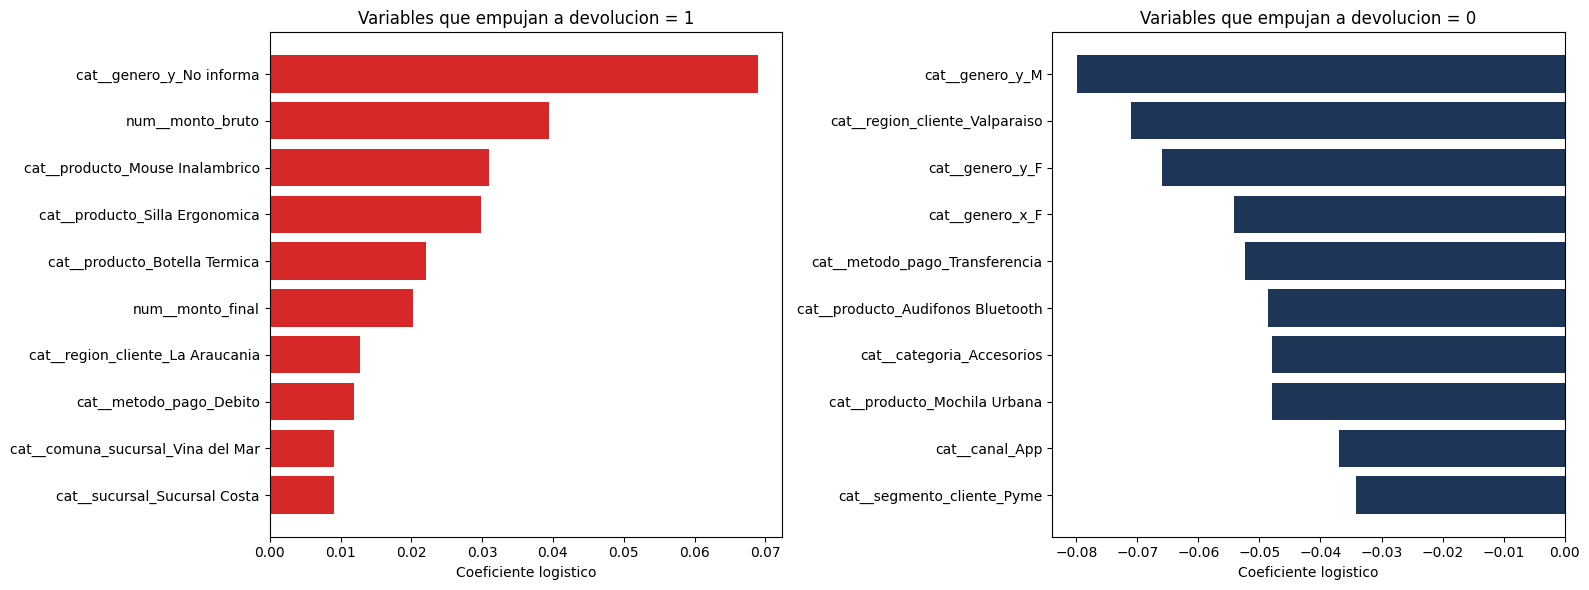

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'modelo' not in globals():
    raise NameError('No se encontro el modelo. Ejecuta primero la celda de modelamiento.')

# Extrae el clasificador desde el pipeline (ultima etapa)
if hasattr(modelo, 'named_steps') and len(modelo.named_steps) > 0:
    nombre_ultimo_paso = list(modelo.named_steps.keys())[-1]
    clasificador = modelo.named_steps[nombre_ultimo_paso]
else:
    clasificador = modelo

if not hasattr(clasificador, 'coef_'):
    raise TypeError('El modelo actual no expone coeficientes. Esta celda esta pensada para regresion logistica.')

# Recupera nombres de variables transformadas
if 'feature_names' in globals() and feature_names is not None and len(feature_names) == clasificador.coef_.shape[1]:
    nombres_variables = np.array(feature_names)
elif 'preprocessor_ml' in globals() and hasattr(preprocessor_ml, 'get_feature_names_out'):
    nombres_variables = preprocessor_ml.get_feature_names_out()
else:
    nombres_variables = np.array([f'var_{i}' for i in range(clasificador.coef_.shape[1])])

coef = clasificador.coef_.ravel()

importancia = pd.DataFrame({
    'variable': nombres_variables,
    'coeficiente': coef,
    'abs_coef': np.abs(coef)
})

# Filtra variables poco interpretables para clase (IDs y fecha exacta)
patrones_excluir = ['venta_id', 'cliente_id', 'producto_id', 'sucursal_id', 'fecha_']
mascara_interpretable = ~importancia['variable'].str.contains('|'.join(patrones_excluir), case=False, regex=True)
importancia_interpretable = importancia[mascara_interpretable].copy()

if importancia_interpretable.empty:
    raise ValueError('No quedaron variables interpretables tras el filtrado. Revisa patrones_excluir.')

importancia_interpretable = importancia_interpretable.sort_values('abs_coef', ascending=False)
top_pos = importancia_interpretable.sort_values('coeficiente', ascending=False).head(10)
top_neg = importancia_interpretable.sort_values('coeficiente', ascending=True).head(10)

print('Top 10 variables interpretables que aumentan la probabilidad de devolucion (coeficiente positivo):')
display(top_pos[['variable', 'coeficiente']])

print('Top 10 variables interpretables que reducen la probabilidad de devolucion (coeficiente negativo):')
display(top_neg[['variable', 'coeficiente']])

# Grafico para presentar en clase
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_pos['variable'][::-1], top_pos['coeficiente'][::-1], color='#d62828')
axes[0].set_title('Variables que empujan a devolucion = 1')
axes[0].set_xlabel('Coeficiente logistico')

axes[1].barh(top_neg['variable'][::-1], top_neg['coeficiente'][::-1], color='#1d3557')
axes[1].set_title('Variables que empujan a devolucion = 0')
axes[1].set_xlabel('Coeficiente logistico')

plt.tight_layout()
plt.show()